In [ ]:
import sys
!{sys.executable} -m pip install umap-learn

  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)

   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

CSV_PATH = "../data/city_lifestyle_dataset.csv"
OUT_PATH = "../outputs/umap_emb_2d.csv"
os.makedirs("outputs", exist_ok=True)

df = pd.read_csv(CSV_PATH)

# Garde uniquement les colonnes numériques (ignore city_name, country, etc.)
X = df.select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

emb = reducer.fit_transform(X_scaled)
emb.shape

e:\anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(300, 2)

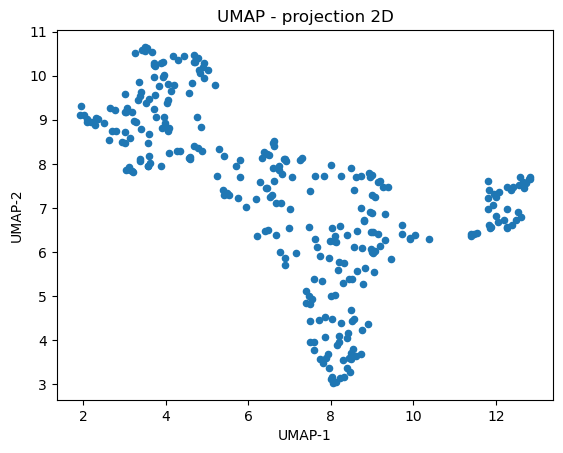

In [ ]:
plt.figure()
plt.scatter(emb[:, 0], emb[:, 1], s=20)
plt.title("UMAP - projection 2D")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

Le gaphique de UMAP1 sur UMAP 2 à une structure non homogène avec un gros groupe principale au centre avec deux autre groupe un en haut à gauche et un a droite. Le groupe en haut à gauche qui représente environs 20 individue et le groupe droite que représente environs 15 individue.

In [ ]:
out = pd.DataFrame(emb, columns=["x", "y"])

# Optionnel: garder le nom de la ville pour te repérer
if "city_name" in df.columns:
    out.insert(0, df["city_name"].values)

out.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

Saved: ../outputs/umap_emb_2d.csv
